Step 1 :Setup

In [0]:
%sql
USE workspace.bde;

In [0]:
import os, gc, pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff4bf154d260>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'


Step 2: Only Using the 0.5% Dataset for Modelling Purposes

In [0]:
# Parameters
DB_TABLE = "taxi_with_locations_final"
SAMPLE_FRAC = 0.001  # 0.5%
RANDOM_STATE = 42
MAX_ROWS = 500_000  # optional cap if even 1% is too big

# Step 1: Sample 1% in Spark
sampled_spark_df = spark.table(DB_TABLE).sample(fraction=SAMPLE_FRAC, seed=RANDOM_STATE)

# Optional: limit rows just in case
sampled_spark_df = sampled_spark_df.limit(MAX_ROWS)

# Step 2: Convert to pandas safely
import pandas as pd
df = sampled_spark_df.toPandas()
print(f"Sampled pandas DataFrame shape: {df.shape}")

# Step 3: Optional — quick check
print(df.head())

Sampled pandas DataFrame shape: (500000, 28)
   VendorID     pickup_datetime  ...               dropoff_zone dropoff_service_zone
0         1 2014-01-01 00:10:47  ...              Midtown South          Yellow Zone
1         1 2014-01-04 11:43:09  ...    Greenwich Village North          Yellow Zone
2         1 2014-01-08 07:03:18  ...  Times Sq/Theatre District          Yellow Zone
3         1 2014-01-11 01:29:46  ...      Upper East Side North          Yellow Zone
4         1 2014-01-12 15:08:45  ...      Upper East Side North          Yellow Zone

[5 rows x 28 columns]


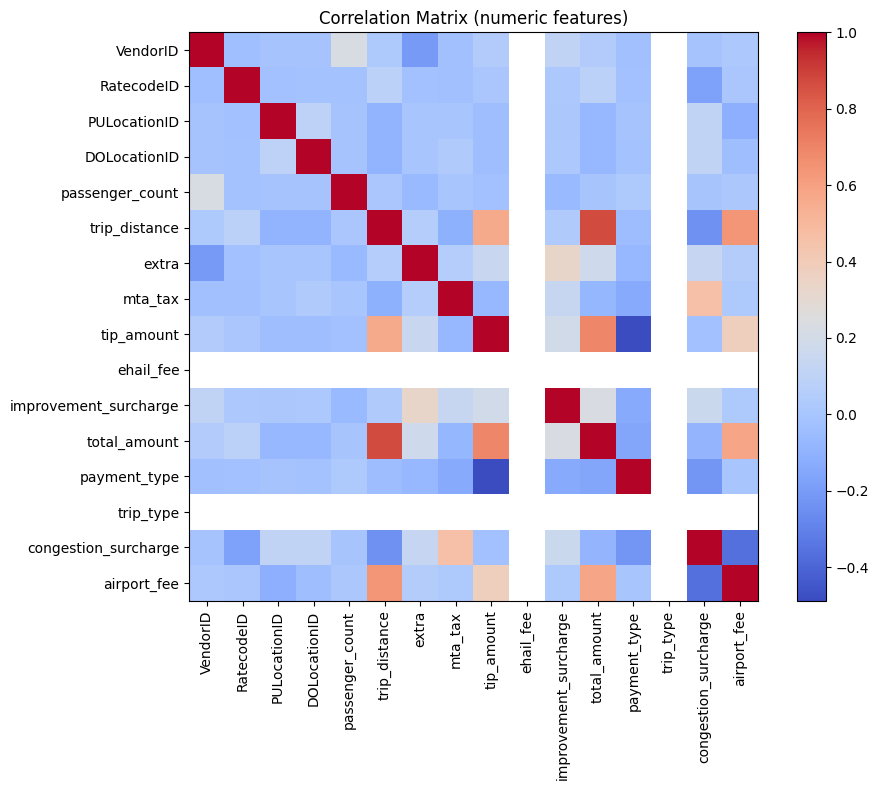

Top correlations with total_amount:
 total_amount             1.000000
trip_distance            0.866627
tip_amount               0.690049
airport_fee              0.579973
improvement_surcharge    0.228305
extra                    0.178794
RatecodeID               0.081905
VendorID                 0.045179
passenger_count         -0.004033
PULocationID            -0.070722
DOLocationID            -0.071565
mta_tax                 -0.075430
congestion_surcharge    -0.081796
payment_type            -0.155470
ehail_fee                     NaN
trip_type                     NaN
Name: total_amount, dtype: float64


In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Exclude target leakage columns
exclude_cols = ["fare_amount", "tolls_amount"]
df_corr = df.drop(columns=exclude_cols, errors="ignore")  # use your sampled df

# Define target
TARGET = "total_amount"

# Select only numeric features
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns

# Compute correlation matrix
corr_matrix = df_corr[numeric_cols].corr()

# --- Plot correlations ---
plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar(im)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix (numeric features)")
plt.tight_layout()
plt.show()

# --- See correlations with target only ---
target_corr = corr_matrix[TARGET].sort_values(ascending=False)
print("Top correlations with total_amount:\n", target_corr)


In [0]:
from sklearn.feature_selection import f_regression, mutual_info_regression

# Categorical features (excluding numeric + target leakage)
categorical_cols = [
    "VendorID", "store_and_fwd_flag", "RatecodeID",
    "PULocationID", "DOLocationID",
    "payment_type", "trip_type",
    "taxi_color", "pickup_borough", "pickup_zone", "pickup_service_zone",
    "dropoff_borough", "dropoff_zone", "dropoff_service_zone"
]

# Encode categoricals as integers for sklearn tests
df_cat = df[categorical_cols].copy()
for col in df_cat.columns:
    df_cat[col] = df_cat[col].astype("category").cat.codes

# Target
y = df["total_amount"]

# --- Option 1: ANOVA F-test ---
f_values, p_values = f_regression(df_cat, y)
anova_corr = pd.Series(f_values, index=categorical_cols).sort_values(ascending=False)
print("ANOVA F-values (higher = stronger relationship with target):")
print(anova_corr)

# --- Option 2: Mutual Information ---
mi = mutual_info_regression(df_cat, y, discrete_features=True, random_state=42)
mi_corr = pd.Series(mi, index=categorical_cols).sort_values(ascending=False)
print("\nMutual Information (higher = stronger relationship with target):")
print(mi_corr)


ANOVA F-values (higher = stronger relationship with target):
RatecodeID              152433.765739
pickup_service_zone     122427.930770
dropoff_service_zone     72163.196137
pickup_borough           31247.548665
payment_type             12384.741604
pickup_zone               3008.110140
DOLocationID              2595.281169
PULocationID              2546.462957
dropoff_zone              2054.627251
VendorID                  1022.634779
store_and_fwd_flag         763.828156
dropoff_borough             79.477360
trip_type                    0.000000
taxi_color                   0.000000
dtype: float64


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff4c408de8e0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex


Mutual Information (higher = stronger relationship with target):
payment_type            0.271798
DOLocationID            0.189096
dropoff_zone            0.189094
VendorID                0.176313
PULocationID            0.157525
pickup_zone             0.157522
dropoff_service_zone    0.125922
RatecodeID              0.120148
pickup_service_zone     0.116494
dropoff_borough         0.115254
pickup_borough          0.106669
store_and_fwd_flag      0.089053
trip_type               0.000452
taxi_color              0.000452
dtype: float64


Feature Selection

In [0]:
# Dropping Columns with Null Value more than 10%
cols_to_drop = ['airport_fee', 'ehail_fee']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Confirm
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['VendorID', 'pickup_datetime', 'dropoff_datetime', 'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge', 'taxi_color', 'pickup_borough', 'pickup_zone', 'pickup_service_zone', 'dropoff_borough', 'dropoff_zone', 'dropoff_service_zone']


In [0]:
# Columns to drop: IDs because irrelevant and because they have very low correlation with target
cols_to_drop = [
    'VendorID',
    'PULocationID',
    'DOLocationID',
    'RatecodeID',
    'tolls_amount',
    'fare_amount',
    'extra',
    'mta_tax',
    'store_and_fwd_flag',
    'congestion_surcharge',
    'improvement_surcharge'
]

# Drop columns safely
df = df.drop(columns=cols_to_drop, errors='ignore')

# Confirm remaining columns
print("Columns after dropping IDs and irrelevant features:\n", df.columns.tolist())


Columns after dropping IDs and irrelevant features:
 ['pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'tip_amount', 'total_amount', 'payment_type', 'trip_type', 'taxi_color', 'pickup_borough', 'pickup_zone', 'pickup_service_zone', 'dropoff_borough', 'dropoff_zone', 'dropoff_service_zone']


Feature Engineering

In [0]:
#extract features like month, day_of_week, hour for time-based predictors.
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year  # extract year

In [0]:
print("Columns after dropping IDs and irrelevant features:\n", df.columns.tolist())


Columns after dropping IDs and irrelevant features:
 ['pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'tip_amount', 'total_amount', 'payment_type', 'trip_type', 'taxi_color', 'pickup_borough', 'pickup_zone', 'pickup_service_zone', 'dropoff_borough', 'dropoff_zone', 'dropoff_service_zone', 'hour', 'day_of_week', 'month', 'year']


One- Hot Encoding for all Categorical Features in the Dataset

In [0]:
categorical_cols = [
    'payment_type', 'trip_type', 'taxi_color',
    'pickup_borough', 'pickup_zone', 'pickup_service_zone',
    'dropoff_borough', 'dropoff_zone', 'dropoff_service_zone',
    'hour', 'day_of_week', 'month'  # treat as categorical
]


Applying One Hot Encoding for Linear Models and Label Encoder for Tree Based

In [0]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pandas as pd

# Define categorical columns
categorical_cols = [
    'payment_type', 'trip_type', 'taxi_color',
    'pickup_borough', 'pickup_zone', 'pickup_service_zone',
    'dropoff_borough', 'dropoff_zone', 'dropoff_service_zone',
    'hour', 'day_of_week', 'month'  # treat as categorical
]


# Create separate copies for each model type
df_linear = df.copy()       # For linear models (OneHotEncoding)
df_tree = df.copy()         # For tree-based models (LabelEncoding)

# -------------------------------
# OneHotEncoding for Linear Models
# -------------------------------
onehotencoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform categorical columns
encoded_array = onehotencoder.fit_transform(df_linear[categorical_cols])

# Convert to DataFrame with proper column names
encoded_df = pd.DataFrame(encoded_array, columns=onehotencoder.get_feature_names_out(categorical_cols), index=df_linear.index)

# Drop original categorical columns and join encoded ones
df_linear_encoded = df_linear.drop(columns=categorical_cols).join(encoded_df)

# -------------------------------
# LabelEncoding for Tree-Based Models
# -------------------------------
for col in categorical_cols:
    label_encoder = LabelEncoder()
    df_tree[col] = label_encoder.fit_transform(df_tree[col].astype(str))

# df_tree is now label-encoded and ready for tree-based models


Outlier Detection

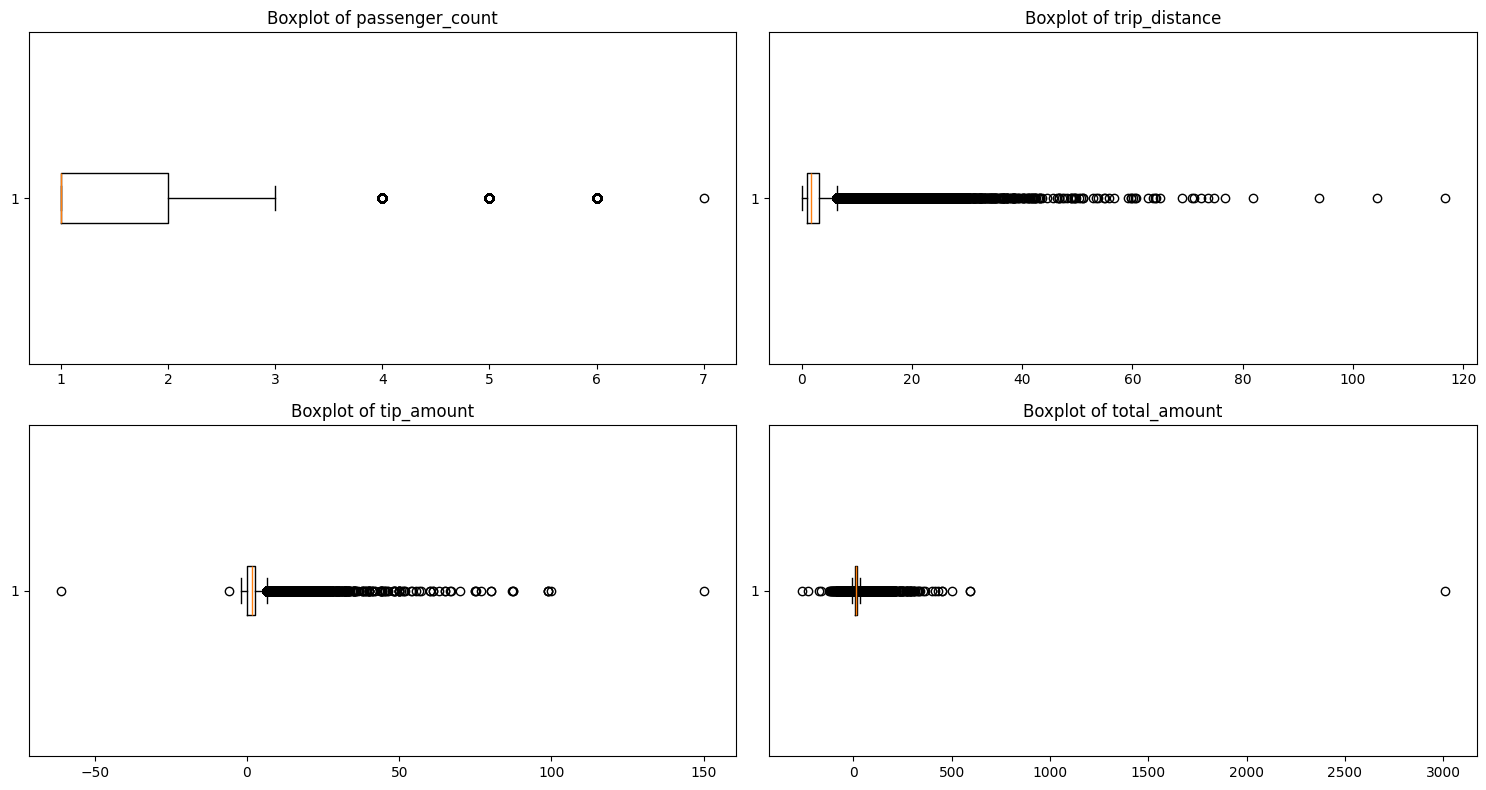

passenger_count: 46883 potential outliers (IQR method)
trip_distance: 54754 potential outliers (IQR method)
tip_amount: 25620 potential outliers (IQR method)
total_amount: 45573 potential outliers (IQR method)


In [0]:
import matplotlib.pyplot as plt

# Numeric columns to check
numeric_cols = ['passenger_count', 'trip_distance', 'tip_amount', 'total_amount']

# 1. Boxplots for quick visual check
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(df_tree[col], vert=False)
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# 2. Quantiles / outlier thresholds
for col in numeric_cols:
    q1 = df_tree[col].quantile(0.25)
    q3 = df_tree[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    num_outliers = ((df_tree[col] < lower_bound) | (df_tree[col] > upper_bound)).sum()
    print(f"{col}: {num_outliers} potential outliers (IQR method)")


Capping Outliers

In [0]:
import pandas as pd
import numpy as np

# List of numeric columns to cap
numeric_cols = ['passenger_count', 'trip_distance', 'tip_amount']

# Cap values at 1st and 99th percentiles
for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)

# Quick check
df[numeric_cols].describe()

,passenger_count,trip_distance,tip_amount
count,500000.000000,500000.000000,500000.000000
mean,1.613494,3.018386,1.942513
std,1.244830,3.626773,2.403568
min,1.000000,0.300000,0.000000
25%,1.000000,1.010000,0.000000
50%,1.000000,1.710000,1.500000
75%,2.000000,3.200000,2.660000
max,6.000000,19.000000,12.550000


Scaling Numeric Features

In [0]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# numeric_cols after outlier capping
numeric_cols = ['passenger_count', 'trip_distance', 'tip_amount', 'total_amount']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', 'passthrough', [col for col in df.columns if col not in numeric_cols])
    ]
)

df_scaled = preprocessor.fit_transform(df)

Train-Test Split for Linear and Random Forest Models

In [0]:
TARGET = "total_amount"

# Boolean masks for train/validation and test sets
train_val_mask = ~((df["month"].isin([10, 11, 12])) & (df["year"] == 2024))
test_mask = (df["month"].isin([10, 11, 12]) & (df["year"] == 2024))

# -------------------------------
#  For Linear Models (OneHotEncoded)
# -------------------------------
X_linear_train = df_linear_encoded[train_val_mask].drop(columns=[TARGET])
y_linear_train = df_linear_encoded.loc[train_val_mask, TARGET]

X_linear_test = df_linear_encoded[test_mask].drop(columns=[TARGET])
y_linear_test = df_linear_encoded.loc[test_mask, TARGET]

# -------------------------------
#  For Tree-Based Models (LabelEncoded)
# -------------------------------
X_tree_train = df_tree[train_val_mask].drop(columns=[TARGET])
y_tree_train = df_tree.loc[train_val_mask, TARGET]

X_tree_test = df_tree[test_mask].drop(columns=[TARGET])
y_tree_test = df_tree.loc[test_mask, TARGET]

# Optional: print shapes
print("Linear model - Train shape:", X_linear_train.shape)
print("Linear model - Test shape:", X_linear_test.shape)
print("Tree model - Train shape:", X_tree_train.shape)
print("Tree model - Test shape:", X_tree_test.shape)


Linear model - Train shape: (494370, 581)
Linear model - Test shape: (5630, 581)
Tree model - Train shape: (494370, 18)
Tree model - Test shape: (5630, 18)


Baseline Model

In [0]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import numpy as np

# Assume your main DataFrame is `df`
# Step 1: Aggregate the baseline table like Q2 3c
baseline_df = (
    df[df['taxi_color'].isin(['yellow','green']) & 
       df['pickup_borough'].notna() & 
       df['dropoff_borough'].notna()]
    .groupby([
        'taxi_color', 'pickup_borough', 'dropoff_borough', 
        'month', 'day_of_week', 'hour'  # already feature-engineered
    ], as_index=False)
    .agg(
        total_trips=('total_amount', 'count'),
        avg_distance_km=('trip_distance', 'mean'),
        avg_amount_per_trip=('total_amount', 'mean'),
        total_amount_paid=('total_amount', 'sum')
    )
)

# Step 2: Merge baseline prediction with train/val data
# Use train_val_df which excludes Oct-Nov-Dec 2024
train_val_df = df[~((df['month'].isin([10,11,12])) & (df['year'] == 2024))]

train_val_with_baseline = train_val_df.merge(
    baseline_df[['taxi_color','pickup_borough','dropoff_borough','month','day_of_week','hour','avg_amount_per_trip']],
    on=['taxi_color','pickup_borough','dropoff_borough','month','day_of_week','hour'],
    how='left'
)

# Step 3: Compute RMSE for baseline
rmse_baseline = np.sqrt(mean_squared_error(
    train_val_with_baseline['total_amount'],
    train_val_with_baseline['avg_amount_per_trip']
))
print(f"Baseline RMSE (train/val): {rmse_baseline:.4f}")

# Step 4: Repeat for test set (Oct-Nov-Dec 2024)
test_df = df[(df['month'].isin([10,11,12])) & (df['year'] == 2024)]
test_with_baseline = test_df.merge(
    baseline_df[['taxi_color','pickup_borough','dropoff_borough','month','day_of_week','hour','avg_amount_per_trip']],
    on=['taxi_color','pickup_borough','dropoff_borough','month','day_of_week','hour'],
    how='left'
)

rmse_test_baseline = np.sqrt(mean_squared_error(
    test_with_baseline['total_amount'],
    test_with_baseline['avg_amount_per_trip']
))
print(f"Baseline RMSE (test Oct-Nov-Dec 2024): {rmse_test_baseline:.4f}")


Baseline RMSE (train/val): 9.4640
Baseline RMSE (test Oct-Nov-Dec 2024): 16.2501


Modelling: Linear Regression

In [0]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# -----------------------------
# Drop datetime columns from features
# -----------------------------
drop_cols = ['pickup_datetime']  # add any other datetime/object columns if needed
X_linear_train = X_linear_train.drop(columns=drop_cols, errors='ignore')
X_linear_test = X_linear_test.drop(columns=drop_cols, errors='ignore')

# Ensure all features are numeric (float64)
X_linear_train = X_linear_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_linear_test = X_linear_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Ensure target is numeric
y_linear_train = y_linear_train.astype(np.float64)
y_linear_test = y_linear_test.astype(np.float64)

# -----------------------------
# Train Linear Regression
# -----------------------------
lr_model = LinearRegression()
lr_model.fit(X_linear_train, y_linear_train)

# -----------------------------
# Predict on train/validation set
# -----------------------------
y_train_pred = lr_model.predict(X_linear_train)
rmse_train = np.sqrt(mean_squared_error(y_linear_train, y_train_pred))
print(f"Linear Regression RMSE (train/val): {rmse_train:.4f}")

# -----------------------------
# Predict on test set
# -----------------------------
y_test_pred = lr_model.predict(X_linear_test)
rmse_test = np.sqrt(mean_squared_error(y_linear_test, y_test_pred))
print(f"Linear Regression RMSE (test): {rmse_test:.4f}")


Linear Regression RMSE (train/val): 15.1672
Linear Regression RMSE (test): 25.6887


Random Forest

In [0]:
# Drop datetime/object columns from tree-based features
drop_cols = ['pickup_datetime']  # add other non-numeric columns if any
X_tree_train = X_tree_train.drop(columns=drop_cols, errors='ignore')
X_tree_test = X_tree_test.drop(columns=drop_cols, errors='ignore')

# Ensure all features are numeric (tree-based models can handle int/float)
X_tree_train = X_tree_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_tree_test = X_tree_test.apply(pd.to_numeric, errors='coerce').fillna(0)

In [0]:
rf_model.fit(X_tree_train, y_tree_train)
y_train_pred_rf = rf_model.predict(X_tree_train)
y_test_pred_rf = rf_model.predict(X_tree_test)

rmse_train_rf = np.sqrt(mean_squared_error(y_tree_train, y_train_pred_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_tree_test, y_test_pred_rf))

print(f"Random Forest RMSE (train/val): {rmse_train_rf:.4f}")
print(f"Random Forest RMSE (test): {rmse_test_rf:.4f}")

Random Forest RMSE (train/val): 2.3046
Random Forest RMSE (test): 15.2490
